# Olist E-commerce: Sales, Customer Experience and Product Analysis

## Project Overview

This project analyzes the performance of the Olist e-commerce platform using data on orders, customers, products and reviews.

The main objective is to identify key patterns in sales performance, customer satisfaction, product categories and geographical distribution of orders.

The analysis focuses on four main areas:

- Sales performance
- Customer experience
- Product categories
- Geographical distribution

## 1. Data Loading and Preparation

The analysis is based on data stored in a PostgreSQL database. Python and Pandas are used for data extraction, transformation and analysis.

The main datasets used in the analysis are:

- Orders
- Order items
- Products
- Customers
- Reviews

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

/Users/altana/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import psycopg2
print("psycopg2 работает")

psycopg2 работает


In [3]:
%pip install psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [4]:
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    port="5432",
    database="olist_analytics",
    user="postgres",
    password="1595"
)

print("Подключение к PostgreSQL успешно!")

Подключение к PostgreSQL успешно!


In [5]:
import pandas as pd

query = """
SELECT *
FROM raw.orders
LIMIT 5;
"""

orders_test = pd.read_sql(query, conn)

orders_test

/var/folders/nv/sjd0d_j15y12zqws9qxy89zh0000gn/T/ipykernel_83942/4249093470.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_test = pd.read_sql(query, conn)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [6]:
orders = pd.read_sql("""
    SELECT *
    FROM raw.orders;
""", conn)

print(f"Количество строк: {len(orders):,}")
print(f"Количество колонок: {orders.shape[1]}")

/var/folders/nv/sjd0d_j15y12zqws9qxy89zh0000gn/T/ipykernel_83942/2543329410.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders = pd.read_sql("""


Количество строк: 99,441
Количество колонок: 8


In [7]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [8]:
order_items = pd.read_sql("""
    SELECT *
    FROM raw.order_items;
""", conn)

print(f"Количество строк: {len(order_items):,}")
print(f"Количество колонок: {order_items.shape[1]}")

/var/folders/nv/sjd0d_j15y12zqws9qxy89zh0000gn/T/ipykernel_83942/2266705593.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  order_items = pd.read_sql("""


Количество строк: 112,650
Количество колонок: 7


## 2. Sales Analysis

This section examines the dynamics of sales over time using Gross Merchandise Value (GMV), the number of orders and Average Order Value (AOV).

In [9]:
sales = order_items.merge(
    orders[['order_id', 'order_purchase_timestamp']],
    on='order_id',
    how='inner'
)

monthly_gmv = (
    sales
    .assign(
        month=sales['order_purchase_timestamp'].dt.to_period('M')
    )
    .groupby('month', as_index=False)
    .agg(
        gmv=('price', 'sum'),
        orders=('order_id', 'nunique')
    )
)

monthly_gmv.head()

,month,gmv,orders
0,2016-09,267.36,3
1,2016-10,"49,507.66",308
2,2016-12,10.90,1
3,2017-01,"120,312.87",789
4,2017-02,"247,303.02",1733


### Monthly GMV — Initial View

The chart below shows the monthly dynamics of Gross Merchandise Value (GMV) across the available observation period.

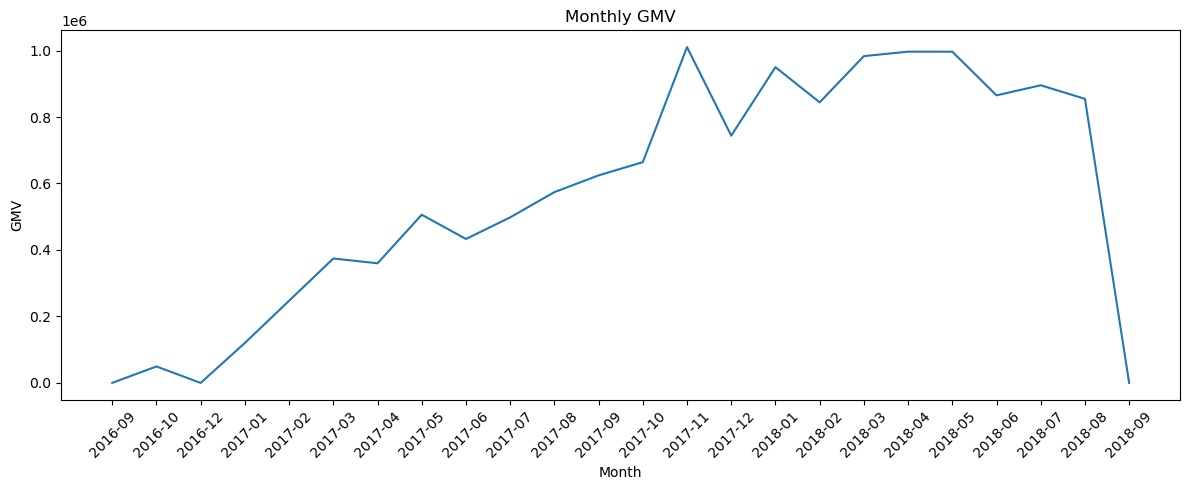

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_gmv['month'].astype(str),
    monthly_gmv['gmv']
)

plt.title('Monthly GMV')
plt.xlabel('Month')
plt.ylabel('GMV')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Data Quality Check

The final month shows an unusually low GMV and only one order. This indicates that the period is incomplete and should not be interpreted as a genuine decline in sales.

In [11]:
monthly_gmv['aov'] = (
    monthly_gmv['gmv'] / monthly_gmv['orders']
)

monthly_gmv

,month,gmv,orders,aov
0,2016-09,267.36,3,89.12
1,2016-10,"49,507.66",308,160.74
2,2016-12,10.90,1,10.90
3,2017-01,"120,312.87",789,152.49
4,2017-02,"247,303.02",1733,142.70
5,2017-03,"374,344.30",2641,141.74
6,2017-04,"359,927.23",2391,150.53
7,2017-05,"506,071.14",3660,138.27
8,2017-06,"433,038.60",3217,134.61
9,2017-07,"498,031.48",3969,125.48


In [12]:
monthly_gmv.tail(6)

,month,gmv,orders,aov
18,2018-04,"996,647.75",6934,143.73
19,2018-05,"996,517.68",6853,145.41
20,2018-06,"865,124.31",6160,140.44
21,2018-07,"895,507.22",6273,142.76
22,2018-08,"854,686.33",6452,132.47
23,2018-09,145.00,1,145.00


In [13]:
monthly_gmv['month'] = monthly_gmv['month'].astype(str)

monthly_gmv

,month,gmv,orders,aov
0,2016-09,267.36,3,89.12
1,2016-10,"49,507.66",308,160.74
2,2016-12,10.90,1,10.90
3,2017-01,"120,312.87",789,152.49
4,2017-02,"247,303.02",1733,142.70
5,2017-03,"374,344.30",2641,141.74
6,2017-04,"359,927.23",2391,150.53
7,2017-05,"506,071.14",3660,138.27
8,2017-06,"433,038.60",3217,134.61
9,2017-07,"498,031.48",3969,125.48


In [14]:
monthly_gmv_clean = monthly_gmv[
    monthly_gmv['orders'] >= 1000
].copy()

monthly_gmv_clean.tail()

,month,gmv,orders,aov
18,2018-04,"996,647.75",6934,143.73
19,2018-05,"996,517.68",6853,145.41
20,2018-06,"865,124.31",6160,140.44
21,2018-07,"895,507.22",6273,142.76
22,2018-08,"854,686.33",6452,132.47


### Monthly GMV — Cleaned Data

The chart below presents the monthly GMV after excluding the incomplete final month from the main trend analysis.

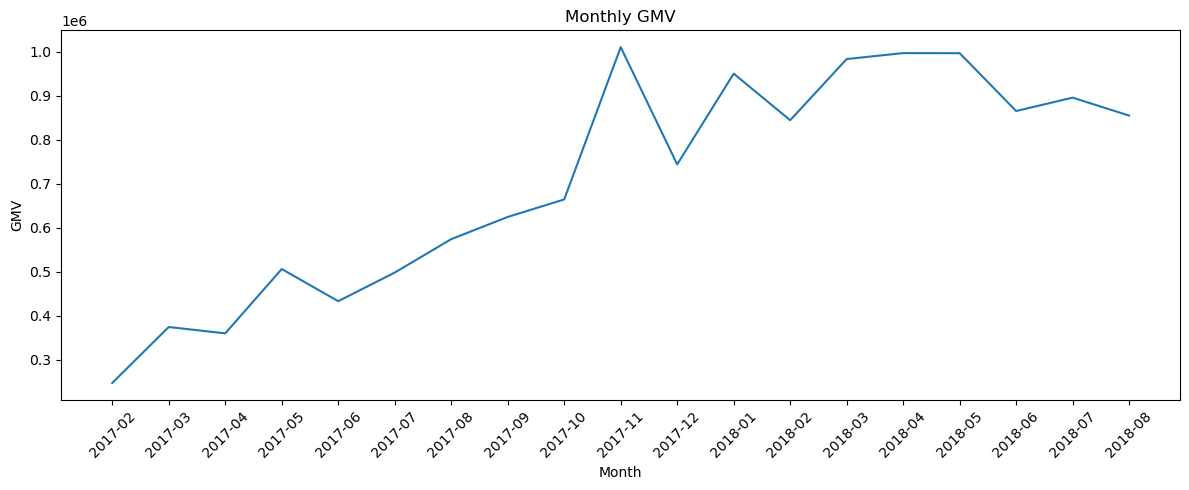

In [15]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_gmv_clean['month'],
    monthly_gmv_clean['gmv']
)

plt.title('Monthly GMV')
plt.xlabel('Month')
plt.ylabel('GMV')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Finding

GMV generally increased during the main observation period, although the growth was not continuous. A decline became visible toward the end of the complete observation period.

### Monthly Order Volume

The chart below shows the monthly number of orders and helps explain the changes observed in GMV.

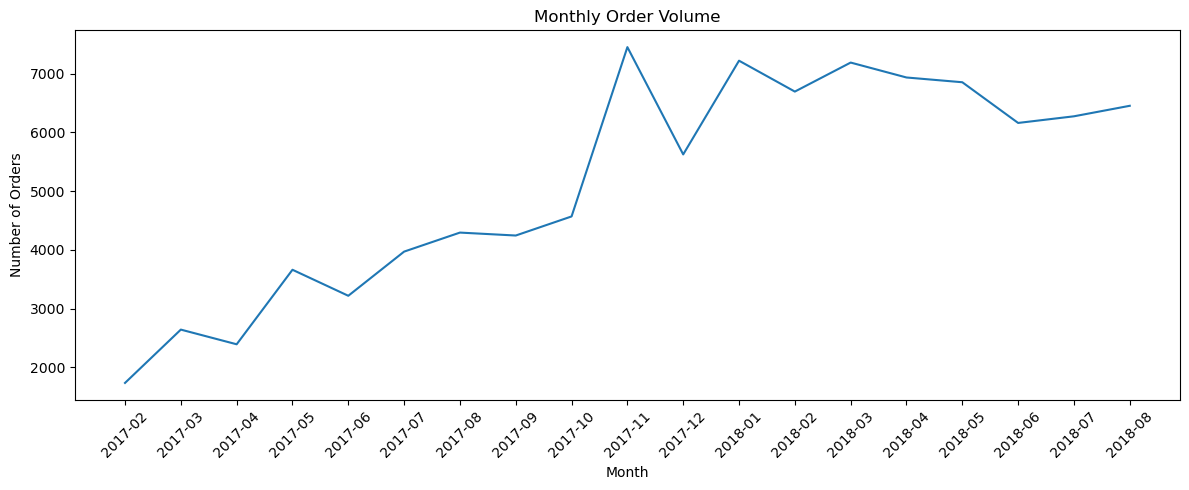

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_gmv_clean['month'],
    monthly_gmv_clean['orders']
)

plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Finding

The dynamics of the number of orders closely follow the dynamics of GMV, suggesting that changes in order volume are strongly associated with changes in total sales.

### Monthly Average Order Value

Average Order Value (AOV) represents the average value of an order and is calculated as total GMV divided by the number of orders.

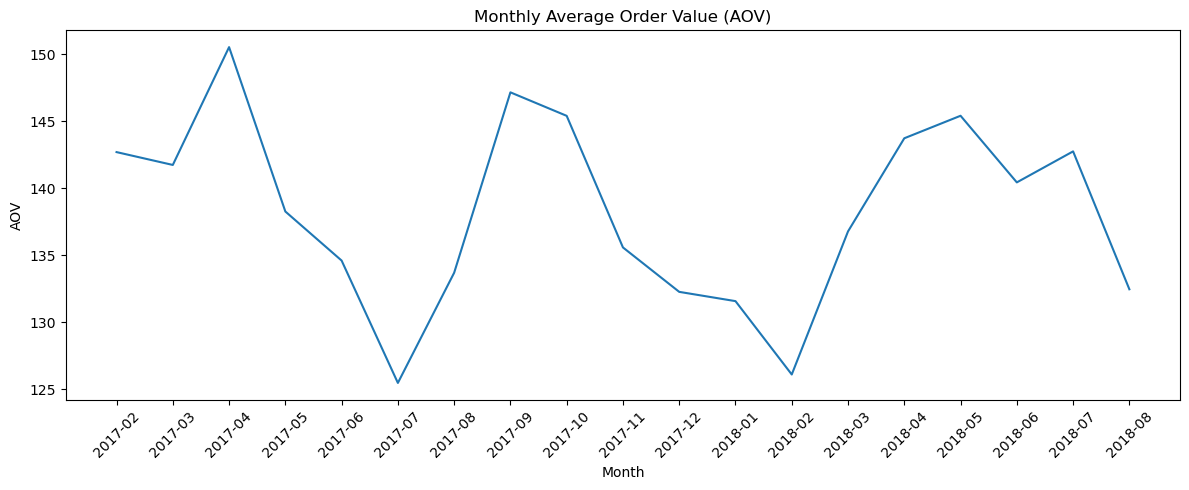

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_gmv_clean['month'],
    monthly_gmv_clean['aov']
)

plt.title('Monthly Average Order Value (AOV)')
plt.xlabel('Month')
plt.ylabel('AOV')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key Finding

AOV fluctuates between approximately 125 and 150 during the analyzed period. Although several noticeable fluctuations are present, changes in order volume appear to have a stronger relationship with overall GMV dynamics.

In [18]:
correlation = monthly_gmv_clean['gmv'].corr(
    monthly_gmv_clean['orders']
)

print(f"Корреляция GMV и количества заказов: {correlation:.3f}")

Корреляция GMV и количества заказов: 0.990


### Sales Summary

The correlation between monthly GMV and the number of orders is 0.990, indicating a very strong positive linear relationship.

This suggests that changes in order volume are strongly associated with changes in monthly GMV, while variations in AOV provide an additional contribution to sales dynamics.

This result should be interpreted as an association rather than a causal relationship.

## 3. Customer Experience Analysis

This section examines the relationship between delivery time and customer satisfaction.

Customer satisfaction is measured using review scores, while delivery time is calculated as the number of days between order purchase and delivery to the customer.

In [19]:
reviews = pd.read_sql("""
    SELECT
        order_id,
        review_score
    FROM raw.reviews;
""", conn)

print(f"Количество отзывов: {len(reviews):,}")

/var/folders/nv/sjd0d_j15y12zqws9qxy89zh0000gn/T/ipykernel_83942/3301227002.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  reviews = pd.read_sql("""


Количество отзывов: 99,224


In [20]:
reviews_delivery = orders[
    [
        'order_id',
        'order_purchase_timestamp',
        'order_delivered_customer_date'
    ]
].merge(
    reviews,
    on='order_id',
    how='inner'
)

reviews_delivery['delivery_days'] = (
    reviews_delivery['order_delivered_customer_date']
    - reviews_delivery['order_purchase_timestamp']
).dt.total_seconds() / 86400

reviews_delivery.head()

,order_id,order_purchase_timestamp,order_delivered_customer_date,review_score,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,4,8.44
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,4,13.78
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,5,9.39
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,5,13.21
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,5,2.87


In [21]:
reviews_delivery['delivery_group'] = pd.cut(
    reviews_delivery['delivery_days'],
    bins=[0, 3, 7, 14, float('inf')],
    labels=['<3 days', '3-7 days', '7-14 days', '14+ days'],
    right=False
)

reviews_delivery['delivery_group'].value_counts().sort_index()

delivery_group
<3 days       4746
3-7 days     21293
7-14 days    40218
14+ days     30102
Name: count, dtype: int64

In [22]:
delivery_analysis = (
    reviews_delivery
    .groupby('delivery_group', observed=True)
    .agg(
        orders=('order_id', 'nunique'),
        avg_review_score=('review_score', 'mean')
    )
    .reset_index()
)

delivery_analysis['avg_review_score'] = (
    delivery_analysis['avg_review_score'].round(2)
)

delivery_analysis

,delivery_group,orders,avg_review_score
0,<3 days,4733,4.48
1,3-7 days,21199,4.40
2,7-14 days,40001,4.31
3,14+ days,29897,3.72


In [23]:
print(
    reviews_delivery[
        ['order_id', 'review_score', 'delivery_days', 'delivery_group']
    ].shape
)

print(
    reviews_delivery['order_id'].nunique()
)

(99224, 4)
98673


In [24]:
reviews_delivery.groupby(
    'delivery_group',
    observed=True
)['order_id'].nunique()

delivery_group
<3 days       4733
3-7 days     21199
7-14 days    40001
14+ days     29897
Name: order_id, dtype: int64

### Average Review Score by Delivery Time

Orders are divided into four delivery-time groups:

- Less than 3 days
- 3–7 days
- 7–14 days
- 14 days or more

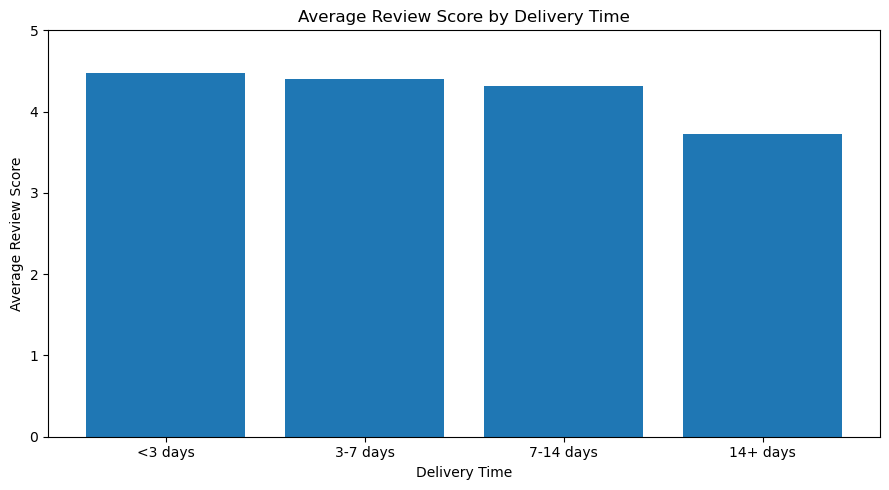

In [25]:
plt.figure(figsize=(9, 5))

plt.bar(
    delivery_analysis['delivery_group'].astype(str),
    delivery_analysis['avg_review_score']
)

plt.title('Average Review Score by Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Average Review Score')
plt.ylim(0, 5)

plt.tight_layout()
plt.show()

### Key Finding

Customer satisfaction decreases as delivery time increases.

The average review score declines from 4.48 for orders delivered in less than 3 days to 3.72 for orders delivered in 14 days or more.

In [26]:
reviews_delivery['is_negative'] = (
    reviews_delivery['review_score'].isin([1, 2])
)

negative_analysis = (
    reviews_delivery
    .groupby('delivery_group', observed=True)
    .agg(
        negative_review_pct=('is_negative', 'mean')
    )
    .reset_index()
)

negative_analysis['negative_review_pct'] = (
    negative_analysis['negative_review_pct'] * 100
).round(2)

negative_analysis

,delivery_group,negative_review_pct
0,<3 days,6.64
1,3-7 days,7.64
2,7-14 days,8.97
3,14+ days,22.59


### Negative Reviews by Delivery Time

A review is classified as negative when the customer gives a score of 1 or 2.

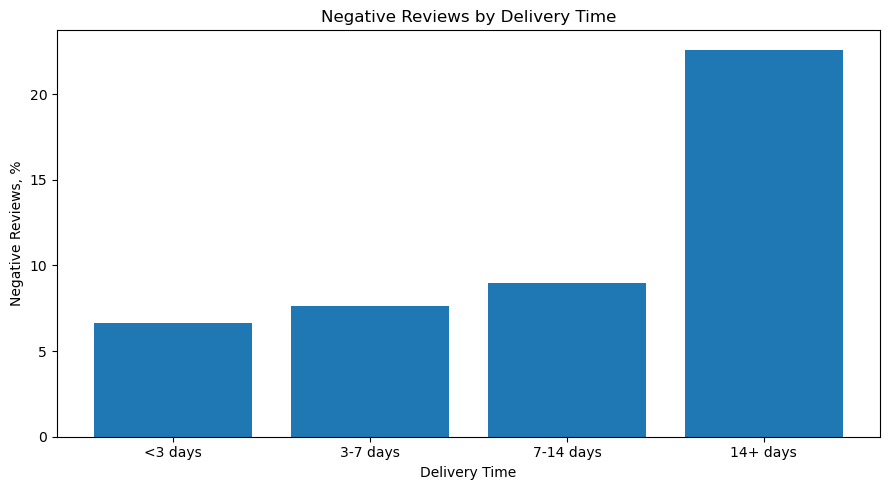

In [27]:
plt.figure(figsize=(9, 5))

plt.bar(
    negative_analysis['delivery_group'].astype(str),
    negative_analysis['negative_review_pct']
)

plt.title('Negative Reviews by Delivery Time')
plt.xlabel('Delivery Time')
plt.ylabel('Negative Reviews, %')

plt.tight_layout()
plt.show()

### Key Finding

The share of negative reviews increases substantially with delivery time.

Negative reviews account for 6.64% of reviews for orders delivered in less than 3 days, compared with 22.59% for orders delivered in 14 days or more.

This represents an increase of approximately 3.4 times.

### Customer Experience Summary

Delivery time is strongly associated with customer satisfaction.

Longer delivery times are accompanied by lower average review scores and a substantially higher share of negative reviews.

Reducing delivery times, particularly for orders taking 14 days or more, may therefore represent an important opportunity to improve customer experience.

However, the analysis identifies an association and does not establish a causal relationship.

## 4. Product Analysis

This section analyzes the contribution of different product categories to total GMV.

The analysis focuses on the top 10 product categories by GMV.

In [28]:
products = pd.read_sql("""
    SELECT
        product_id,
        product_category_name
    FROM raw.products;
""", conn)

print(f"Количество товаров: {len(products):,}")

Количество товаров: 32,951


/var/folders/nv/sjd0d_j15y12zqws9qxy89zh0000gn/T/ipykernel_83942/3858001577.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products = pd.read_sql("""


In [29]:
category_sales = order_items.merge(
    products,
    on='product_id',
    how='left'
)

category_sales.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim


In [30]:
category_gmv = (
    category_sales[
        category_sales['product_category_name'].notna()
    ]
    .groupby('product_category_name')
    .agg(
        orders=('order_id', 'nunique'),
        gmv=('price', 'sum')
    )
    .reset_index()
    .sort_values('gmv', ascending=False)
)

category_gmv.head(10)

,product_category_name,orders,gmv
11,beleza_saude,8836,"1,258,681.34"
66,relogios_presentes,5624,"1,205,005.68"
13,cama_mesa_banho,9417,"1,036,988.68"
32,esporte_lazer,7720,"988,048.97"
44,informatica_acessorios,6689,"911,954.32"
54,moveis_decoracao,6449,"729,762.49"
26,cool_stuff,3632,"635,290.85"
72,utilidades_domesticas,5884,"632,248.66"
8,automotivo,3897,"592,720.11"
40,ferramentas_jardim,3518,"485,256.46"


### Top 10 Product Categories by GMV

The chart below presents the product categories generating the highest GMV.

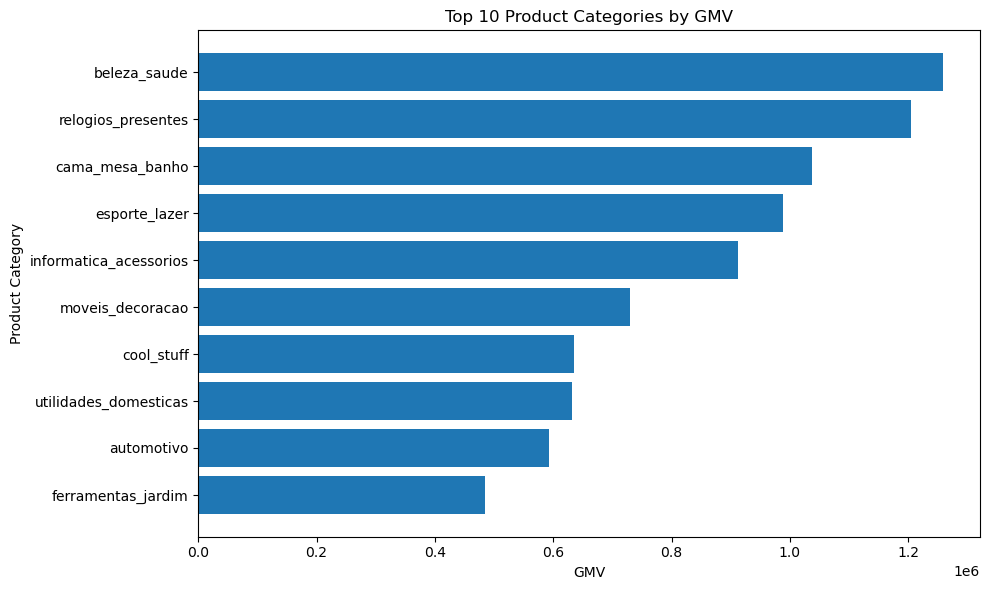

In [31]:
top10 = category_gmv.head(10).sort_values('gmv')

plt.figure(figsize=(10, 6))

plt.barh(
    top10['product_category_name'],
    top10['gmv']
)

plt.title('Top 10 Product Categories by GMV')
plt.xlabel('GMV')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

### Key Finding

The largest GMV contributions come from categories such as `beleza_saude`, `relogios_presentes`, `cama_mesa_banho` and `esporte_lazer`.

The leading category is `beleza_saude`, with GMV of approximately 1.26 million.

The results indicate that sales are concentrated in several major product categories.

In [32]:
category_avg_price = (
    category_sales[
        category_sales['product_category_name'].notna()
    ]
    .groupby('product_category_name')
    .agg(
        orders=('order_id', 'nunique'),
        gmv=('price', 'sum'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

category_avg_price['avg_price'] = (
    category_avg_price['avg_price'].round(2)
)

category_avg_price.sort_values(
    'avg_price',
    ascending=False
).head(10)

,product_category_name,orders,gmv,avg_price
61,pcs,181,"222,963.13","1,098.34"
64,portateis_casa_forno_e_cafe,75,"47,445.71",624.29
29,eletrodomesticos_2,234,"113,317.74",476.12
0,agro_industria_e_comercio,182,"72,530.47",342.12
45,instrumentos_musicais,628,"191,498.88",281.62
31,eletroportateis,630,"190,648.58",280.78
65,portateis_cozinha_e_preparadores_de_alimentos,14,"3,968.53",264.57
71,telefonia_fixa,217,"59,583.00",225.69
25,construcao_ferramentas_seguranca,167,"40,544.52",208.99
66,relogios_presentes,5624,"1,205,005.68",201.14


## 5. Geographical Analysis

This section examines the geographical distribution of orders across Brazilian states.

In [33]:
customers = pd.read_sql("""
    SELECT
        customer_id,
        customer_state
    FROM raw.customers;
""", conn)

print(f"Количество клиентов: {len(customers):,}")

/var/folders/nv/sjd0d_j15y12zqws9qxy89zh0000gn/T/ipykernel_83942/1040175742.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("""


Количество клиентов: 99,441


In [34]:
orders_customers = orders[
    ['order_id', 'customer_id']
].merge(
    customers,
    on='customer_id',
    how='left'
)

orders_customers.head()

,order_id,customer_id,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,SP


In [35]:
state_orders = (
    orders_customers
    .groupby('customer_state')
    .agg(
        orders=('order_id', 'nunique')
    )
    .reset_index()
    .sort_values('orders', ascending=False)
)

state_orders.head(10)

,customer_state,orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


### Top 10 States by Number of Orders

The chart below shows the Brazilian states with the highest number of orders.

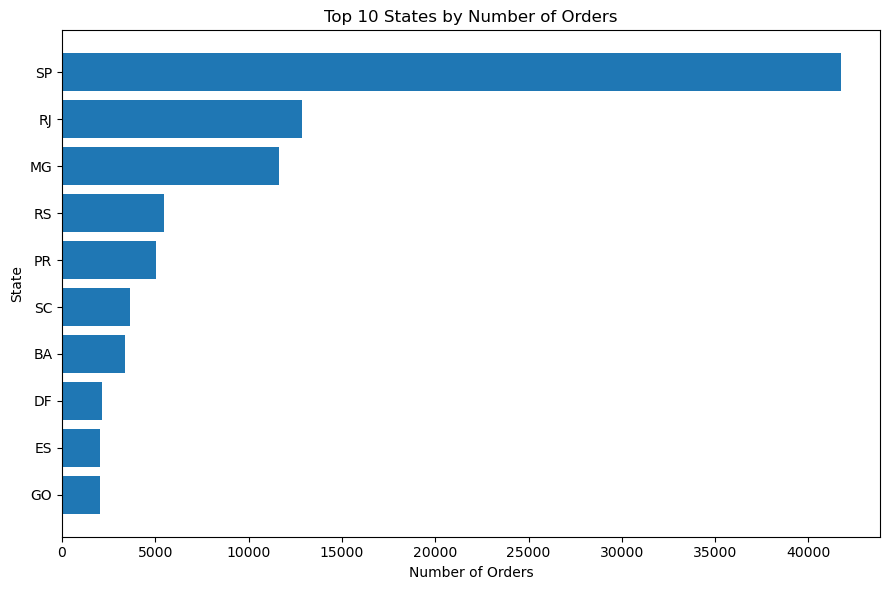

In [36]:
top_states = state_orders.head(10).sort_values('orders')

plt.figure(figsize=(9, 6))

plt.barh(
    top_states['customer_state'],
    top_states['orders']
)

plt.title('Top 10 States by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('State')

plt.tight_layout()
plt.show()

### Key Finding

Orders are geographically concentrated in a limited number of Brazilian states.

São Paulo (SP) is the dominant market with 41,746 orders, substantially ahead of Rio de Janeiro (RJ) and Minas Gerais (MG).

# 6. Final Conclusions

The analysis of Olist e-commerce data revealed several key patterns.

### 1. Sales Performance

Monthly GMV is strongly associated with order volume. The correlation between GMV and the number of orders equals 0.990, indicating a very strong positive relationship.

### 2. Customer Experience

Delivery time is strongly associated with customer satisfaction. The average review score decreases from 4.48 for deliveries under 3 days to 3.72 for deliveries taking 14 days or more.

At the same time, the share of negative reviews increases from 6.64% to 22.59%.

### 3. Product Structure

A relatively small number of product categories generate a substantial share of GMV. The leading categories include `beleza_saude`, `relogios_presentes`, `cama_mesa_banho` and `esporte_lazer`.

### 4. Geographical Concentration

Orders are highly concentrated geographically. São Paulo is the largest market, with 41,746 orders, substantially exceeding the number of orders in other states.

## Business Implications

Based on the analysis, three potential areas for improvement can be identified:

- reducing long delivery times, especially deliveries exceeding 14 days;
- maintaining and increasing order volume as a key driver of sales;
- focusing commercial and marketing efforts on high-performing product categories and major geographical markets.

Overall, the analysis shows that delivery performance, order volume and category structure are important dimensions of Olist's e-commerce performance.